In [ ]:
# Imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import (
    model_selection as skms,
    metrics,
    tree,
    preprocessing as skpre,
    pipeline,
    neighbors,
    naive_bayes,
    linear_model,
    dummy
)
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Imports OK ')

Imports OK ✅


In [ ]:
# Load data 
df = pd.read_csv('nba_salaries.csv', index_col=0)
print(f'Raw shape: {df.shape}')
display(df.head())
df.info()

Raw shape: (467, 31)


,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,curryst01
1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,walljo01
2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,westbru01
3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,jamesle01
4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,duranke01


<class 'pandas.core.frame.DataFrame'>
Index: 467 entries, 0 to 466
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player Name        467 non-null    object 
 1   Salary             467 non-null    int64  
 2   Position           467 non-null    object 
 3   Age                467 non-null    int64  
 4   Team               467 non-null    object 
 5   GP                 467 non-null    int64  
 6   GS                 467 non-null    int64  
 7   MP                 467 non-null    float64
 8   FG                 467 non-null    float64
 9   FGA                467 non-null    float64
 10  FG%                466 non-null    float64
 11  3P                 467 non-null    float64
 12  3PA                467 non-null    float64
 13  3P%                454 non-null    float64
 14  2P                 467 non-null    float64
 15  2PA                467 non-null    float64
 16  2P%                463 non-null

In [ ]:
# Cleaning
df_clean = df.copy()

# Create binary target BEFORE dropping Salary
THRESHOLD = 10_000_000
df_clean['SalaryTier'] = (df_clean['Salary'] >= THRESHOLD).map({True: 'High', False: 'Low'})
print('Target distribution:')
print(df_clean['SalaryTier'].value_counts())

# Drop non-feature columns
df_clean.drop(columns=['Salary', 'Player Name', 'Team', 'Player-additional'], inplace=True)

# Simplify hyphenated positions
df_clean['Position'] = df_clean['Position'].str.split('-').str[0]

# Fill missing shooting % with 0 (no attempts → 0%)
pct_cols = ['FG%', '3P%', '2P%', 'eFG%', 'FT%']
df_clean[pct_cols] = df_clean[pct_cols].fillna(0)

print(f'\nMissing values after cleaning:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}')
print(f'\nClean shape: {df_clean.shape}')
display(df_clean.head())

Target distribution:
SalaryTier
Low     343
High    124
Name: count, dtype: int64

Missing values after cleaning:
Series([], dtype: int64)

Clean shape: (467, 28)


,Position,Age,GP,GS,MP,FG,FGA,FG%,3P,3PA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,SalaryTier
0,PG,34,56,56,34.7,10.0,20.2,0.493,4.9,11.4,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,High
1,PG,32,34,3,22.2,4.1,9.9,0.408,1.0,3.2,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,High
2,PG,34,73,24,29.1,5.9,13.6,0.436,1.2,3.9,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,High
3,PF,38,55,54,35.5,11.1,22.2,0.500,2.2,6.9,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,High
4,PF,34,47,47,35.6,10.3,18.3,0.560,2.0,4.9,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,High


In [ ]:
# Feature matrix & target
# One-hot encode Position
df_encoded = pd.get_dummies(df_clean, columns=['Position'], drop_first=False)

y = df_encoded['SalaryTier']
X = df_encoded.drop(columns=['SalaryTier'])

print('Feature columns:', X.columns.tolist())
print(f'X shape: {X.shape}, y shape: {y.shape}')

Feature columns: ['Age', 'GP', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Position_C', 'Position_PF', 'Position_PG', 'Position_SF', 'Position_SG']
X shape: (467, 31), y shape: (467,)


In [ ]:
# Train / Test split (stratified 80/20)
X_trainval, X_test, y_trainval, y_test = skms.train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train+Val: {X_trainval.shape[0]} samples')
print(f'Test:      {X_test.shape[0]} samples')
print(f'\nClass balance (train+val):\n{y_trainval.value_counts()}')

Train+Val: 373 samples
Test:      94 samples

Class balance (train+val):
SalaryTier
Low     274
High     99
Name: count, dtype: int64


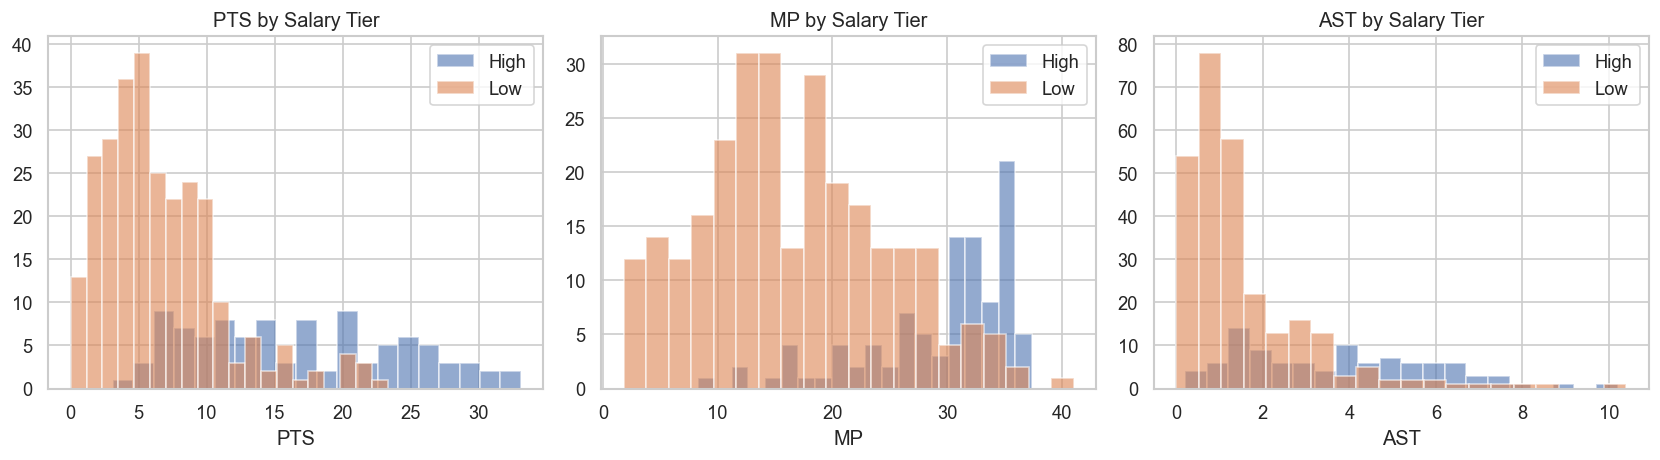

In [ ]:
# Quick EDA on training set 
# Reconstruct df for plotting purposes
eda_df = X_trainval.copy()
eda_df['SalaryTier'] = y_trainval.values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['PTS', 'MP', 'AST']):
    for tier, grp in eda_df.groupby('SalaryTier'):
        ax.hist(grp[col], bins=20, alpha=0.6, label=tier)
    ax.set_title(f'{col} by Salary Tier')
    ax.set_xlabel(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Define 5 model variations
models_to_try = {
    '1_Dummy (Baseline)':                dummy.DummyClassifier(strategy='most_frequent'),
    '2_Decision Tree (depth=3)':         tree.DecisionTreeClassifier(max_depth=3, random_state=42),
    '3_Decision Tree (depth=10)':        tree.DecisionTreeClassifier(max_depth=10, random_state=42),
    '4_Random Forest (100t, depth=5)':   RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    '5_Random Forest (200t, no limit)':  RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
}

cv = skms.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models_to_try.items():
    pipe = pipeline.Pipeline([
        ('scaler', skpre.StandardScaler()),
        ('clf', model)
    ])
    acc_scores = skms.cross_val_score(pipe, X_trainval, y_trainval, cv=cv, scoring='accuracy')
    # Note: DummyClassifier doesn't support predict_proba with most_frequent for roc_auc → skip for baseline
    try:
        auc_scores = skms.cross_val_score(pipe, X_trainval, y_trainval, cv=cv,
                                          scoring='roc_auc')
        mean_auc = auc_scores.mean()
    except Exception:
        mean_auc = np.nan

    results.append({
        'Model': name,
        'CV Accuracy (mean)': acc_scores.mean().round(4),
        'CV Accuracy (std)':  acc_scores.std().round(4),
        'CV ROC-AUC (mean)':  round(mean_auc, 4) if not np.isnan(mean_auc) else 'N/A'
    })
    print(f'{name}: Acc={acc_scores.mean():.4f} ± {acc_scores.std():.4f}')

results_df = pd.DataFrame(results)
display(results_df)

1_Dummy (Baseline): Acc=0.7346 ± 0.0045
2_Decision Tree (depth=3): Acc=0.8792 ± 0.0313
3_Decision Tree (depth=10): Acc=0.8551 ± 0.0316
4_Random Forest (100t, depth=5): Acc=0.8711 ± 0.0331
5_Random Forest (200t, no limit): Acc=0.8712 ± 0.0307


,Model,CV Accuracy (mean),CV Accuracy (std),CV ROC-AUC (mean)
0,1_Dummy (Baseline),0.7346,0.0045,0.5000
1,2_Decision Tree (depth=3),0.8792,0.0313,0.8553
2,3_Decision Tree (depth=10),0.8551,0.0316,0.8105
3,"4_Random Forest (100t, depth=5)",0.8711,0.0331,0.9274
4,"5_Random Forest (200t, no limit)",0.8712,0.0307,0.9283


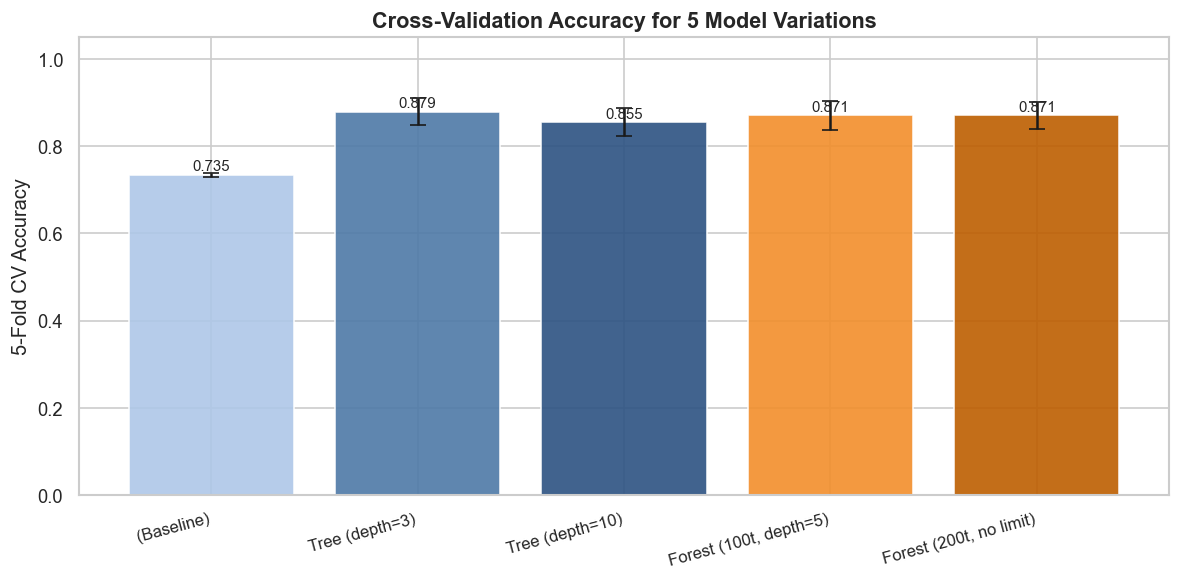

In [ ]:
# Visualise cross-validation accuracy 
fig, ax = plt.subplots(figsize=(10, 5))

model_names  = results_df['Model']
mean_acc     = results_df['CV Accuracy (mean)'].astype(float)
std_acc      = results_df['CV Accuracy (std)'].astype(float)
colors = ['#aec7e8', '#4e79a7', '#2c5282', '#f28e2b', '#bd5e00']

bars = ax.bar(range(len(model_names)), mean_acc, yerr=std_acc,
              capsize=5, color=colors, edgecolor='white', alpha=0.9)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels([n.split(' ', 1)[1] for n in model_names], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Cross-Validation Accuracy for 5 Model Variations', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
for bar, v in zip(bars, mean_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

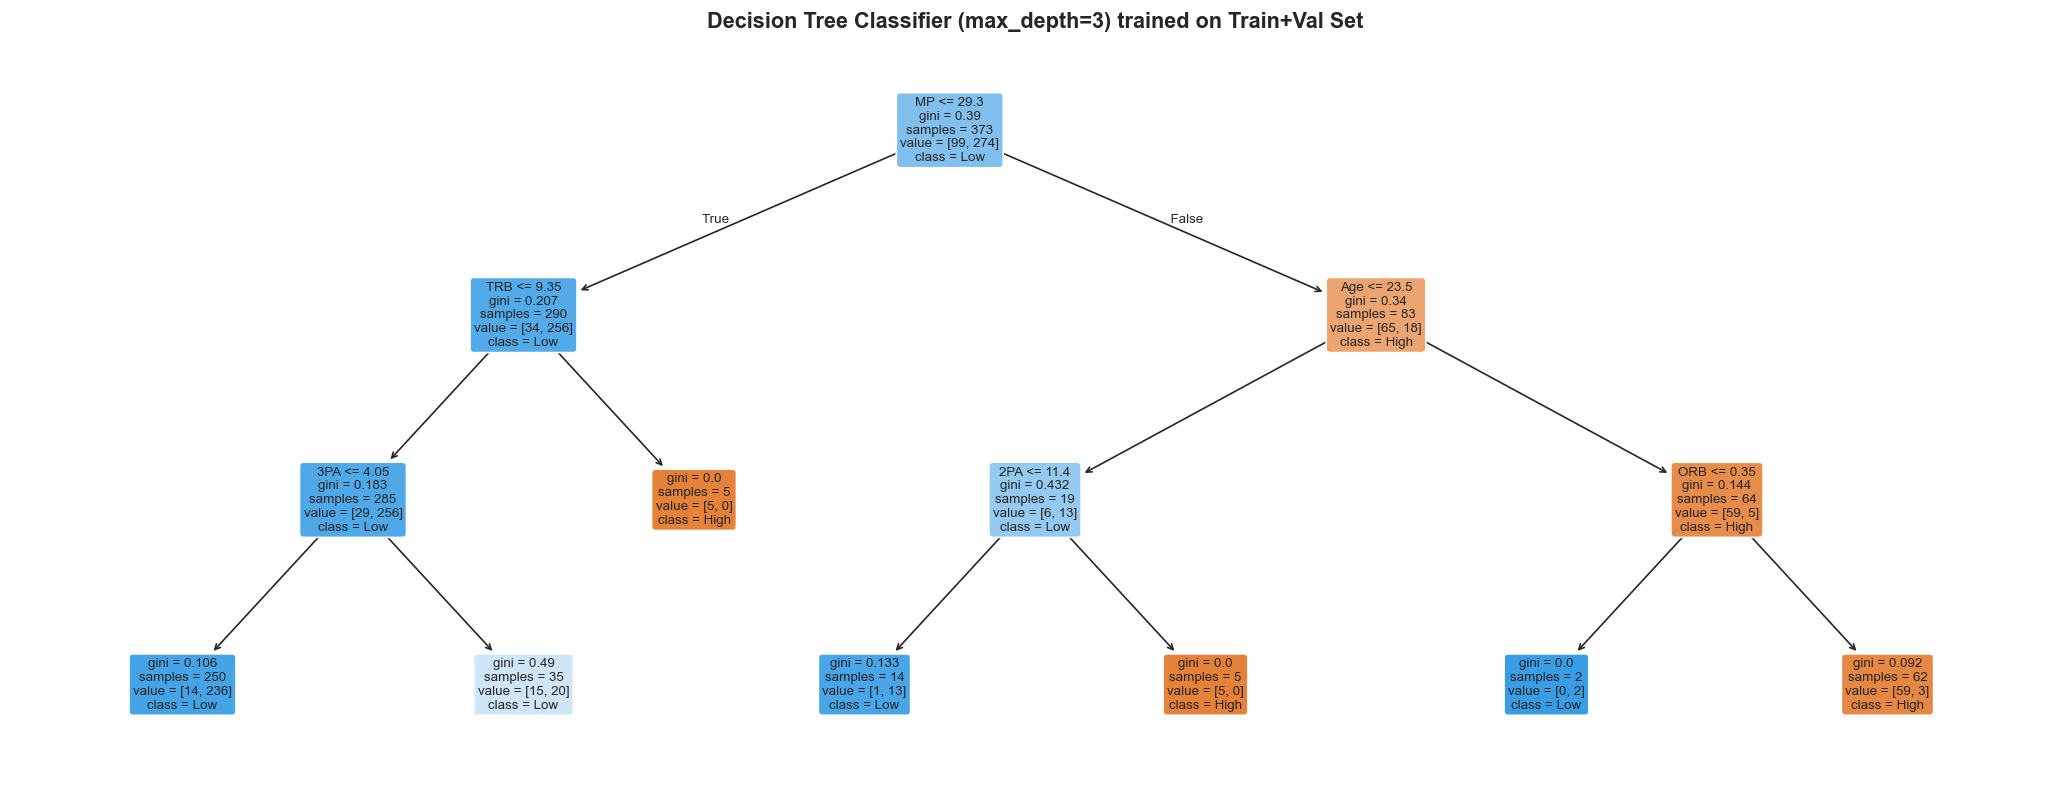

In [ ]:
# Visualise one of the decision trees (depth=3)
# Train just the DTC on full train+val set for visualization
dtc_viz = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
dtc_viz.fit(X_trainval, y_trainval)

plt.figure(figsize=(22, 8), dpi=120)
tree.plot_tree(dtc_viz,
               filled=True,
               feature_names=X_trainval.columns.tolist(),
               class_names=['High', 'Low'],
               rounded=True,
               fontsize=8)
plt.title('Decision Tree Classifier (max_depth=3) trained on Train+Val Set', fontsize=13, fontweight='bold')
plt.show()

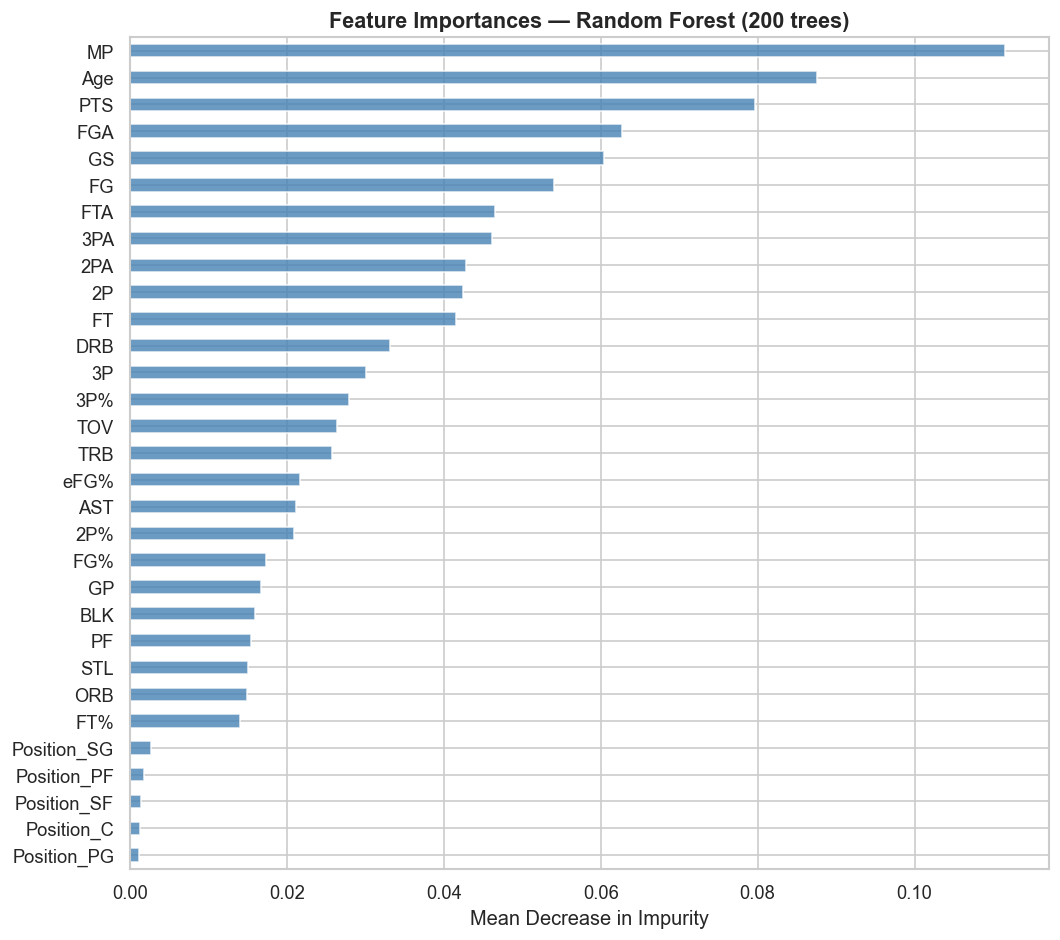

In [ ]:
# Feature importances from the best Random Forest
# Train best RF on full train+val for importance plot
best_rf_for_plot = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
best_rf_for_plot.fit(X_trainval, y_trainval)

importances = pd.Series(best_rf_for_plot.feature_importances_, index=X_trainval.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
importances_sorted.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Feature Importances — Random Forest (200 trees)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

In [ ]:
# Final model: retrain on full train+val, evaluate on test 
final_model = pipeline.Pipeline([
    ('scaler', skpre.StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42))
])
final_model.fit(X_trainval, y_trainval)

y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]  # probability of 'Low' class

test_acc = metrics.accuracy_score(y_test, y_pred)
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'\nClassification Report:')
print(metrics.classification_report(y_test, y_pred))

Test Accuracy:  0.8617

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.56      0.68        25
         Low       0.86      0.97      0.91        69

    accuracy                           0.86        94
   macro avg       0.87      0.77      0.80        94
weighted avg       0.86      0.86      0.85        94



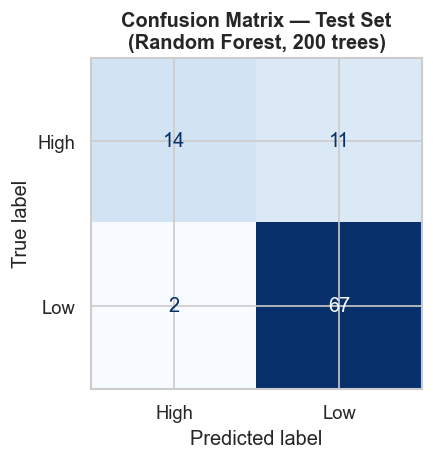

In [ ]:
# Confusion matrix 
cm = metrics.confusion_matrix(y_test, y_pred, labels=['High', 'Low'])
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set\n(Random Forest, 200 trees)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

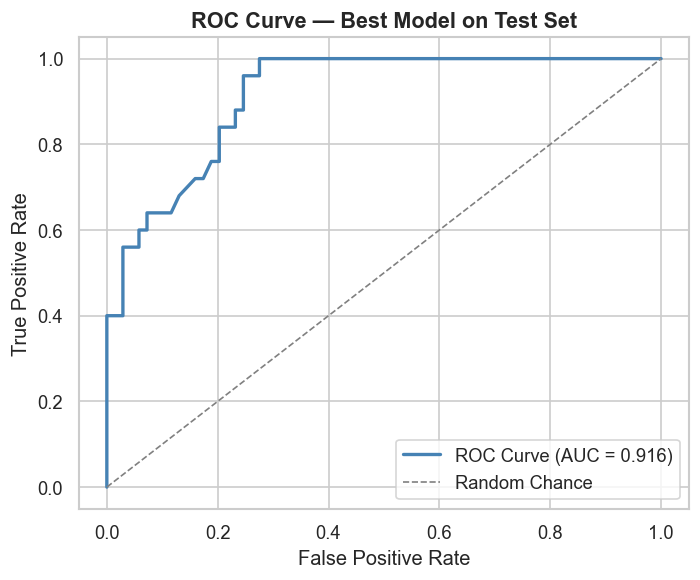

ROC-AUC on test set: 0.9159


In [ ]:
# ROC Curve
# Encode target as 0/1 for ROC (High=1, Low=0)
label_enc = skpre.LabelEncoder()
y_test_bin = label_enc.fit_transform(y_test)  # High→0, Low→1 (alphabetical)
# We want High=1, so invert if needed
if label_enc.classes_[0] == 'High':
    # predict_proba column 0 = 'High' → use column 0 as score for High
    y_score_high = final_model.predict_proba(X_test)[:, 0]
    y_test_bin_high = (y_test == 'High').astype(int)
else:
    y_score_high = final_model.predict_proba(X_test)[:, 1]
    y_test_bin_high = (y_test == 'High').astype(int)

fpr, tpr, _ = metrics.roc_curve(y_test_bin_high, y_score_high)
roc_auc = metrics.auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Best Model on Test Set', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ROC-AUC on test set: {roc_auc:.4f}')